# Guide: Read and visualize the Isharah-2000 pose PKL file

PKL file is a dictionary:

```python
pose_dict[sample_id]['keypoints']
```

where each `keypoints` array has shape:

```python
(T, J, 2)
```

For this old format, the joint order is:

- `0:21`   → right hand
- `21:42`  → left hand
- `42:61`  → lips (**19 landmarks**)
- `61:`    → body

The notebook below will:
1. load the PKL file
2. explain how to read one sample
3. visualize one selected sample inside the notebook
4. save a few rendered frames if you want


In [3]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import pandas as pd

# ==============================
# User settings
# ==============================
PKL_PATH = Path('pose_data_isharah2000_hands_lips_body.pkl')   # change this
VIDEO_ID = None                             # example: '00_0001'; None -> use first sample
FRAME_INDEX = 0                             # frame to visualize
SAVE_RENDERED_FRAMES = False
SAVE_DIR = Path('pose_rendered_frames')
MAX_FRAMES_TO_SAVE = 6
FRAME_STRIDE = 10

# ==============================
# Metadata Path
# ==============================
train_metadata_path = Path('../../metadata/isharah500/train.csv')
dev_metadata_path = Path('../../metadata/isharah500/dev.csv')
test_metadata_path = Path('../../metadata/isharah500/test.csv')

# ==============================
# Old PKL layout
# ==============================
NUM_RH = 21
NUM_LH = 21
NUM_LIPS = 19   # IMPORTANT: old PKL uses 19 lip landmarks

assert PKL_PATH.exists(), f'File not found: {PKL_PATH}'
print('Using PKL file:', PKL_PATH.resolve())


Using PKL file: /home/tuan/HuuTuan/GitHubRepository/cslr-project/data/isharah500/pose_data_isharah2000_hands_lips_body.pkl


Get id of Videos

In [4]:
# ==============================
# Load metadata
# ==============================
train_metadata = pd.read_csv(train_metadata_path)
dev_metadata = pd.read_csv(dev_metadata_path)
test_metadata = pd.read_csv(test_metadata_path)

# ==============================
# Get video IDs for train/dev/test splits
# ==============================
train_ids = train_metadata['sample_id'].tolist()
dev_ids = dev_metadata['sample_id'].tolist()
test_ids = test_metadata['sample_id'].tolist()

In [5]:
full_ids = train_ids + dev_ids + test_ids

## Load the PKL and inspect one sample

In [6]:
# ==============================
# Load full pose data from PKL file
# ==============================
with open(PKL_PATH, 'rb') as f:
    pose_dict = pickle.load(f)

/tmp/ipykernel_24918/1491267382.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  pose_dict = pickle.load(f)


In [7]:
for sample_id in full_ids:
    if sample_id not in pose_dict:
        print(f'Warning: sample_id {sample_id} not found in PKL data.')
    else:
        sample_data = pose_dict[sample_id]
        with open(f"pose/{sample_id}.pkl", "wb") as f:
            pickle.dump(sample_data, f)


In [ ]:
if VIDEO_ID is None:
    sample_id = next(iter(pose_dict.keys()))
else:
    sample_id = VIDEO_ID
    assert sample_id in pose_dict, f'{sample_id} not found in PKL'

sample = pose_dict[sample_id]
print('\nSelected sample:', sample_id)
print('Sample keys:', list(sample.keys()))

pose_data = sample['keypoints']
print('keypoints type :', type(pose_data))
print('keypoints shape:', pose_data.shape)

assert isinstance(pose_data, np.ndarray)
assert pose_data.ndim == 3, f'Expected (T, J, 2), got {pose_data.shape}'
T, J, D = pose_data.shape
assert D == 2, f'Expected last dim = 2, got {D}'

num_body = J - (NUM_RH + NUM_LH + NUM_LIPS)
print('\nInterpreted layout:')
print(f'  right hand : 0:{NUM_RH}')
print(f'  left hand  : {NUM_RH}:{NUM_RH + NUM_LH}')
print(f'  lips       : {NUM_RH + NUM_LH}:{NUM_RH + NUM_LH + NUM_LIPS}')
print(f'  body       : {NUM_RH + NUM_LH + NUM_LIPS}:')
print(f'  inferred body joints = {num_body}')


/tmp/ipykernel_14890/1247504329.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  pose_dict = pickle.load(f)


Top-level type: <class 'dict'>
Number of samples: 30000
First 10 sample IDs:
['00_0001', '00_0002', '00_0003', '00_0004', '00_0005', '00_0006', '00_0007', '00_0008', '00_0009', '00_0010']

Selected sample: 00_0001
Sample keys: ['keypoints']
keypoints type : <class 'numpy.ndarray'>
keypoints shape: (55, 86, 2)
keypoints dtype: float64

Interpreted layout:
  right hand : 0:21
  left hand  : 21:42
  lips       : 42:61
  body       : 61:
  inferred body joints = 25


## How to read the pose data

This is the exact way to slice one frame or a full sequence.

In [5]:
# Full sequence slices
right_hand_seq = pose_data[:, 0:21, :]
left_hand_seq  = pose_data[:, 21:42, :]
lips_seq       = pose_data[:, 42:61, :]
body_seq       = pose_data[:, 61:, :]

print('Sequence slice shapes:')
print('  right hand:', right_hand_seq.shape)
print('  left hand :', left_hand_seq.shape)
print('  lips      :', lips_seq.shape)
print('  body      :', body_seq.shape)

# One frame slices
frame = pose_data[FRAME_INDEX]
right_hand = frame[0:21]
left_hand  = frame[21:42]
lips       = frame[42:61]
body       = frame[61:]

print('\nOne frame shapes:')
print('  frame      :', frame.shape)
print('  right hand :', right_hand.shape)
print('  left hand  :', left_hand.shape)
print('  lips       :', lips.shape)
print('  body       :', body.shape)


Sequence slice shapes:
  right hand: (55, 21, 2)
  left hand : (55, 21, 2)
  lips      : (55, 19, 2)
  body      : (55, 25, 2)

One frame shapes:
  frame      : (86, 2)
  right hand : (21, 2)
  left hand  : (21, 2)
  lips       : (19, 2)
  body       : (25, 2)


## Visualize one sample in this notebook

This cell renders one frame directly in the notebook.

Notes:
- Hands are drawn with hand connections.
- Lips are drawn as points only.
- Body is drawn with connections only if its joint count matches the expected upper-body subset; otherwise body points only are shown.


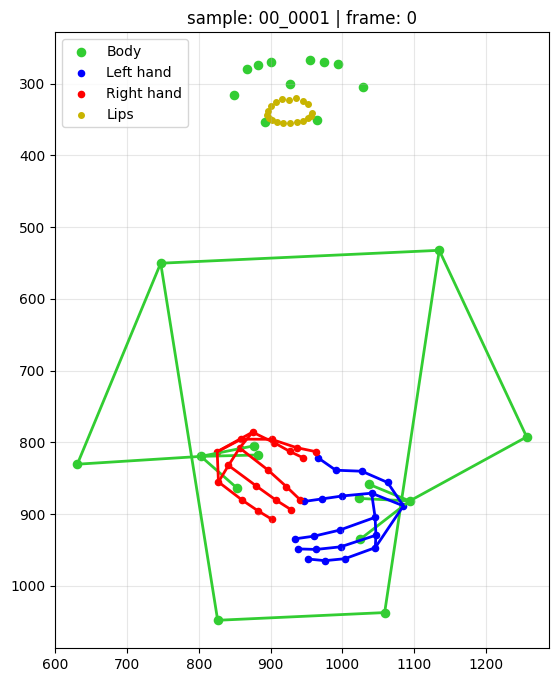

In [6]:
# Hand topology
HAND_CONNECTIONS = [
    (0,1), (1,2), (2,3), (3,4),
    (0,5), (5,6), (6,7), (7,8),
    (5,9), (9,10), (10,11), (11,12),
    (9,13), (13,14), (14,15), (15,16),
    (13,17), (17,18), (18,19), (19,20),
    (0,17)
]

# Expected upper-body subset, if present in the old PKL body section
UPPER_BODY_IDXS = [
    0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 12,
    13, 14,
    15, 16,
    17, 18, 19, 20, 21, 22,
    23, 24,
]

UPPER_BODY_CONNECTIONS_ORIG = [
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (15, 17), (15, 19), (15, 21),
    (16, 18), (16, 20), (16, 22),
    (11, 23), (12, 24), (23, 24),
]

def build_local_connections(selected_indices, original_connections):
    idx_map = {orig_idx: local_idx for local_idx, orig_idx in enumerate(selected_indices)}
    local_connections = []
    for a, b in original_connections:
        if a in idx_map and b in idx_map:
            local_connections.append((idx_map[a], idx_map[b]))
    return local_connections

BODY_CONNECTIONS = build_local_connections(UPPER_BODY_IDXS, UPPER_BODY_CONNECTIONS_ORIG)

def draw_connections(ax, pts, connections, color, linewidth=2):
    for a, b in connections:
        if 0 <= a < len(pts) and 0 <= b < len(pts):
            ax.plot([pts[a, 0], pts[b, 0]], [pts[a, 1], pts[b, 1]], color=color, linewidth=linewidth)

def render_frame_matplotlib(frame_xy, title=None):
    rh = frame_xy[0:21]
    lh = frame_xy[21:42]
    lip = frame_xy[42:61]
    bd = frame_xy[61:]

    fig, ax = plt.subplots(figsize=(8, 8))

    body_has_connections = len(bd) == len(UPPER_BODY_IDXS)
    if body_has_connections:
        draw_connections(ax, bd, BODY_CONNECTIONS, color='limegreen', linewidth=2)

    draw_connections(ax, lh, HAND_CONNECTIONS, color='blue', linewidth=2)
    draw_connections(ax, rh, HAND_CONNECTIONS, color='red', linewidth=2)

    if len(bd) > 0:
        ax.scatter(bd[:, 0], bd[:, 1], c='limegreen', s=35, label='Body')
    ax.scatter(lh[:, 0], lh[:, 1], c='blue', s=20, label='Left hand')
    ax.scatter(rh[:, 0], rh[:, 1], c='red', s=20, label='Right hand')
    ax.scatter(lip[:, 0], lip[:, 1], c='#c8b400', s=16, label='Lips')

    ax.invert_yaxis()  # match image coordinate system
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')
    if title is not None:
        ax.set_title(title)
    plt.show()

frame_xy = pose_data[FRAME_INDEX]
render_frame_matplotlib(frame_xy, title=f'sample: {sample_id} | frame: {FRAME_INDEX}')


## Optional: save a few rendered frames

In [ ]:
if SAVE_RENDERED_FRAMES:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    saved = 0
    for t in range(0, T, FRAME_STRIDE):
        frame_xy = pose_data[t]
        rh = frame_xy[0:21]
        lh = frame_xy[21:42]
        lip = frame_xy[42:61]
        bd = frame_xy[61:]

        fig, ax = plt.subplots(figsize=(8, 8))
        body_has_connections = len(bd) == len(UPPER_BODY_IDXS)
        if body_has_connections:
            draw_connections(ax, bd, BODY_CONNECTIONS, color='limegreen', linewidth=2)
        draw_connections(ax, lh, HAND_CONNECTIONS, color='blue', linewidth=2)
        draw_connections(ax, rh, HAND_CONNECTIONS, color='red', linewidth=2)
        if len(bd) > 0:
            ax.scatter(bd[:, 0], bd[:, 1], c='limegreen', s=35, label='Body')
        ax.scatter(lh[:, 0], lh[:, 1], c='blue', s=20, label='Left hand')
        ax.scatter(rh[:, 0], rh[:, 1], c='red', s=20, label='Right hand')
        ax.scatter(lip[:, 0], lip[:, 1], c='#c8b400', s=16, label='Lips')
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')
        ax.set_title(f'sample: {sample_id} | frame: {t}')

        out_path = SAVE_DIR / f'{sample_id}_frame_{t:05d}.png'
        fig.savefig(out_path, bbox_inches='tight', dpi=150)
        plt.close(fig)
        print('Saved:', out_path)
        saved += 1
        if saved >= MAX_FRAMES_TO_SAVE:
            break
else:
    print('Saving is disabled. Set SAVE_RENDERED_FRAMES = True to export images.')
